## Importy a načtení dat

In [1]:
import networkx as nx
import networkx.algorithms.community as nx_comm
import csv
import numpy as np

import matplotlib.pyplot as plt

import timeit

In [2]:
base_network_path = "./Base.gexf"
labels_file = "../ogbn-arxiv/raw/node-label.csv"
years_file = "../ogbn-arxiv/raw/node_year.csv"
features_file = "../ogbn-arxiv/raw/node_year.csv"

In [3]:
with open(labels_file, "r") as file:
    labels_content = np.array(list(csv.reader(file)), dtype=np.int8)

with open(years_file, "r") as file:
    years_content = np.array(list(csv.reader(file)), dtype=np.int16)

## Rychlá analýza dat

In [30]:
label_counts = np.unique_counts(labels_content)
years_counts = np.unique_counts(years_content)

In [31]:
label_counts

UniqueCountsResult(values=array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39], dtype=int8), counts=array([  565,   687,  4839,  2080,  5862,  4958,  1618,   589,  6232,
        2820,  7869,   750,    29,  2358,   597,   403, 27321,   515,
         749,  2877,  2076,   393,  1903,  2834, 22187,  1257,  4605,
        4801, 21406,   416, 11814,  2828,   411,  1271,  7867,   127,
        3524,  2369,  1507,  2029]))

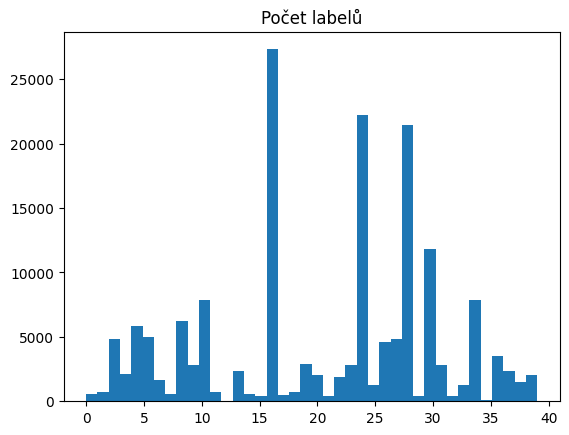

In [32]:
plt.title("Počet labelů")
plt.hist(labels_content, bins=40)
plt.show()

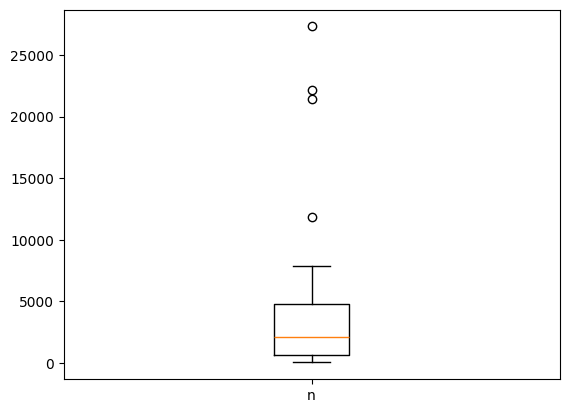

In [33]:
plt.title("")
plt.boxplot(label_counts.counts, tick_labels=["n"])
plt.show()

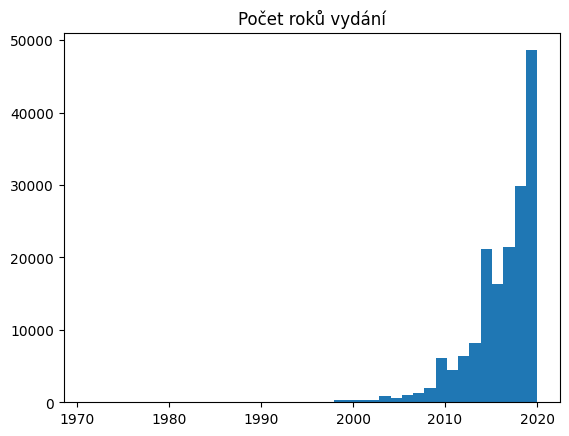

In [34]:
plt.title("Počet roků vydání")
plt.hist(years_content, bins=40)
plt.show()

## Detekce komunit

### Louvain

In [ ]:
G: nx.Graph = nx.read_gexf(base_network_path)
communities_louvain = nx_comm.louvain_communities(G, seed=42)

In [ ]:
len(communities_louvain)

159

Bylo nalezeno 159 komunit, což je mnohem více, než kolik je v datech tříd (40).

In [ ]:
# Vložení ground truth do souboru
nx.set_node_attributes(G, {node: {"ground_truth": labels_content[int(node)][0]} for node in G.nodes})

In [ ]:
# Vložení idx komunity nalezené pomocí funkce
for idx, community in enumerate(communities_louvain):
    for node in community:
        nx.set_node_attributes(G, {node: {"louvain": idx}})

In [ ]:
print(G.nodes["0"]["ground_truth"], G.nodes["0"]["louvain"])

4 120


Nalezené komunity nebudou přesně reflektovat ground_truth. Budu testovat oproti nejčetnější komunitě pro třídu

In [ ]:
from collections import defaultdict

In [ ]:
true_pred = defaultdict(list[int])
for node in G.nodes:
    node_data = G.nodes[node]
    true_ = node_data["ground_truth"]
    predicted = node_data["louvain"]
    true_pred[true_].append(predicted)

Pro zjištění nejčetnějšího labelu využiji bincount + argmax. V některých případech se může stát, že se ground_truth rozdělí na více velkých částí.

In [ ]:
np.bincount(true_pred[0])

array([  2,   6,   0,   7,   0,   0, 144, 113,   0,   1,   0,   0,   0,
         0,   0, 107,   0,   0,   0,   1,   0,   0,   2,   1,   0,   0,
         0,  16,   0,   0,   0,   0,   0,   0,   4,   0,   0,   0,  15,
         6,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   3,   0,   0,  11,   0,   0,   0,   0,   6,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,  24,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,   1,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  20,   0,
         0,   0,   4,   0,   0,   0,   0,   2,   0,   0,   0,   0,   0,
        14,   0,   0,   1,  38,   4,   0,   0,   0,   0,   0,   0,   0,
         0,   2,   0,   0,   6,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3])

zde lze vidět, že nejčetnější louvain komunity jsou [6, 7, 15]

In [ ]:
counts = np.bincount(true_pred[0])
# Labely, které jsou >= max-0.3max (rozmezí <0.3max; max>)
np.where((counts >= counts.max() - counts.max()*0.3))[0]

array([ 6,  7, 15])

In [ ]:
np.bincount(true_pred[0]).max() / len(true_pred[0])

np.float64(0.25486725663716814)

Můžeme říct, že pro třídu 0 má louvain accuracy ~25%?

Co když budeme testovat proti dříve definovanému rozmezí? Můžeme to udělat?

In [ ]:
accuracies = []
for label, preds in true_pred.items():
    # print(preds)
    preds_num = np.bincount(preds).max()
    accuracies.insert(label, preds_num / len(preds))

accuracies = np.array(accuracies)
accuracies

array([0.25486726, 0.16302766, 0.13473424, 0.25673077, 0.52659127,
       0.72494317, 0.62310919, 0.26315789, 0.2833804 , 0.37546912,
       0.32639379, 0.50567376, 0.24137931, 0.54813864, 0.32666667,
       0.3101737 , 0.51504251, 0.39029126, 0.17257854, 0.62646566,
       0.41255007, 0.31503368, 0.7478434 , 0.27905004, 0.11959288,
       0.74267101, 0.56009165, 0.42322991, 0.27181091, 0.53721045,
       0.65002627, 0.86092771, 0.17307692, 0.78949904, 0.63195233,
       0.27100042, 0.36810467, 0.82297404, 0.4015748 , 0.36009732])

Některé třídy jsou poměrně dobře napamované s accuracy ~80%.

In [ ]:
accuracies.sum() / len(accuracies)

np.float64(0.4326783078548275)

Objevují se louvain komunity i v jiných třídách?

In [ ]:
len(set([a for a in true_pred[0] if a in true_pred[1]]))

19

Ano, určitě. Třídy 0 a 1 mají 19 společných komunit. Jak se s tímto vypořádat?

#### Spočtení metrik NMI, ARI a F1

In [ ]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, f1_score

In [ ]:
y_true = []
y_pred = []

for node in G.nodes:
    node_data = G.nodes[node]
    y_true.append(node_data["ground_truth"])
    y_pred.append(node_data["louvain"])

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
nmi = normalized_mutual_info_score(y_true, y_pred)
ari = adjusted_rand_score(y_true, y_pred)

print(f"NMI: {nmi:.4f}")
print(f"ARI: {ari:.4f}")

NMI: 0.4020
ARI: 0.2838


In [ ]:
from scipy.optimize import linear_sum_assignment

In [ ]:
true_labels = np.unique(y_true)
pred_labels = np.unique(y_pred)

# kontingenční matice (komunity × třídy)
cost_matrix = np.zeros((len(pred_labels), len(true_labels)))

for i, p in enumerate(pred_labels):
    for j, t in enumerate(true_labels):
        cost_matrix[i, j] = np.sum((y_pred == p) & (y_true == t))

# ===== Hungarian mapping =====
row_ind, col_ind = linear_sum_assignment(-cost_matrix)

mapping = {pred_labels[row]: true_labels[col] for row, col in zip(row_ind, col_ind)}

# ===== doplnění chybějících komunit =====
for p in pred_labels:
    if p not in mapping:
        mask = (y_pred == p)
        majority_class = np.bincount(y_true[mask]).argmax()
        mapping[p] = majority_class

# ===== přemapování =====
y_pred_mapped = np.array([mapping[p] for p in y_pred])

# ===== F1 =====
macro_f1 = f1_score(y_true, y_pred_mapped, average='macro')

print(f"Macro-F1: {macro_f1:.4f}")

Macro-F1: 0.2158


#### Výsledné evaluační metriky pro louvain komunity:
|NMI|ARI|F1-MACRO|
|--|--|--|
|0.4020|0.2838|0.2158|

#### Uložení do gephy souboru (pro vizualizace)

In [ ]:
nx.write_gexf(G, "communities.gexf")

### Detekce pomocí embeddingů

In [19]:
from ogb.nodeproppred import NodePropPredDataset
import torch

In [6]:
import ogb
print(ogb.__version__)

1.3.6


In [12]:
dataset = NodePropPredDataset(name='ogbn-arxiv', root='../ogbn-arxiv/')
graph, y = dataset[0]

Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<?, ?it/s]

Saving...


In [13]:
y = y.squeeze()
y

array([ 4,  5, 28, ..., 10,  4,  1], shape=(169343,))

In [14]:
split_idx = dataset.get_idx_split()

train_idx = split_idx['train']
valid_idx = split_idx['valid']
test_idx  = split_idx['test']

In [145]:
def sample_few_shot(idx, y, num_classes, k):
    few_shot_idx = []

    for c in range(num_classes):
        class_idx = idx[y[idx] == c]
        perm = np.random.permutation(len(class_idx))[:k]
        few_shot_idx.append(class_idx[perm])

    return np.concatenate(few_shot_idx)

In [180]:
def compute_centroids(Z, y, idx, num_classes):
    centroids = []

    for c in range(num_classes):
        class_idx = idx[y[idx] == c]
        z_c = Z[class_idx]              
        centroid = z_c.mean(axis=0)     
        centroids.append(centroid)

    return np.stack(centroids)          

In [237]:
few_idx = sample_few_shot(train_idx, y, num_classes=40, k=50000)

In [211]:
embeddings: np.ndarray = dataset[0][0]["node_feat"]

In [238]:
centroids = compute_centroids(embeddings, y, few_idx, 40)

Zjištění nejbližších uzlů k centroidům můžemezjistit pomocí torch

In [239]:
torch.cdist(torch.tensor(embeddings), torch.tensor(centroids)).argmax(dim=1) # dimenze 1 jsou kosinovy podobnosti

tensor([14, 38, 14,  ..., 20, 14, 14])

In [240]:
predicted_embedding = torch.cdist(torch.tensor(embeddings), torch.tensor(centroids)).argmax(dim=1)

In [202]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, f1_score

In [207]:
G = nx.read_gexf("communities.gexf")

In [208]:
y_true = []

for node in G.nodes:
    node_data = G.nodes[node]
    y_true.append(node_data["ground_truth"])

y_true = np.array(y_true)

In [241]:
nmi = normalized_mutual_info_score(y_true, predicted_embedding)
ari = adjusted_rand_score(y_true, predicted_embedding)

print(f"NMI: {nmi:.4f}")
print(f"ARI: {ari:.4f}")

NMI: 0.0012
ARI: 0.0003


#### Výsledné evaluační metriky pro mean embedding centroidy:
|NMI|ARI|F1-MACRO|
|--|--|--|
|0.0012|0.0003|--|

In [250]:
import torch.nn.functional as F

# Převedeme embeddingy na PyTorch tensor hned na začátku
emb_tensor = torch.tensor(embeddings, dtype=torch.float32)

k_shot = 5
num_classes = 40
representatives_dict = {}

for c in range(num_classes):
    # Indexy trénovacích uzlů pro danou třídu
    class_idx = train_idx[y[train_idx] == c]
    class_emb = emb_tensor[class_idx]
    
    # Centroid podle průměru
    centroid = class_emb.mean(dim=0, keepdim=True)
    
    sim_to_centroid = F.cosine_similarity(class_emb, centroid)
    
    topk_indices = sim_to_centroid.topk(min(k_shot, len(class_idx))).indices
    
    representatives_dict[c] = class_emb[topk_indices]

In [251]:
similarity_profiles = torch.zeros((len(embeddings), num_classes))

emb_norm = F.normalize(emb_tensor, p=2, dim=1)

for c in range(num_classes):
    reps = representatives_dict[c]
    reps_norm = F.normalize(reps, p=2, dim=1)
    
    sim_matrix = torch.matmul(emb_norm, reps_norm.T)
    
    avg_sim = sim_matrix.mean(dim=1)
    
    # Maximální podobnost
    # max_sim = sim_matrix.max(dim=1).values 
    
    similarity_profiles[:, c] = avg_sim

predicted_embedding = similarity_profiles.argmax(dim=1).numpy()

In [252]:
nmi = normalized_mutual_info_score(y_true, predicted_embedding)
ari = adjusted_rand_score(y_true, predicted_embedding)

print(f"NMI: {nmi:.4f}")
print(f"ARI: {ari:.4f}")

NMI: 0.0014
ARI: 0.0000


In [ ]:
from sklearn.cluster import KMeans

# Převedeme na PyTorch tensor a znormalizujeme na délku 1 (L2 normalizace)
# Tím zajistíme, že K-Means bude efektivně fungovat na bázi kosinové podobnosti
emb_tensor = torch.tensor(embeddings, dtype=torch.float32)
emb_norm = F.normalize(emb_tensor, p=2, dim=1).numpy()

# Počet komunit nastavíme na 40 (odpovídá počtu ground-truth tříd v datasetu)
num_clusters = 40

# Inicializujeme K-Means. 
# random_state=42 zaručí, že výsledek bude při každém spuštění stejný.
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)

# fit_predict rovnou najde centroidy a zároveň každému uzlu přiřadí ID jeho komunity
predicted_kmeans = kmeans.fit_predict(emb_norm)


# Nyní můžeme rovnou spočítat NMI a ARI (stejně jako jste to dělal u Louvaina)
# y_true už máte načtené z předchozích buněk
nmi_kmeans = normalized_mutual_info_score(y_true, predicted_kmeans)
ari_kmeans = adjusted_rand_score(y_true, predicted_kmeans)

print(f"K-Means NMI: {nmi_kmeans:.4f}")
print(f"K-Means ARI: {ari_kmeans:.4f}")

# Pokud byste chtěl spočítat i F1-Macro, musíte nejprve aplikovat 
# Hungarian mapping (linear_sum_assignment) úplně stejně, jako jste 
# to udělal ve vašem kódu pro Louvain komunity.

1. Příprava a normalizace dat...
2. Spouštím K-Means clustering pro 40 komunit...
   (To může u 169 tisíc uzlů trvat několik desítek vteřin...)
3. K-Means hotovo! Vyhodnocuji...

--- VÝSLEDKY K-MEANS (Obsahové komunity) ---
K-Means NMI: 0.0014
K-Means ARI: -0.0001


#### Výsledné evaluační metriky pro K-Means embedding centroidy:
|NMI|ARI|F1-MACRO|
|--|--|--|
|0.0014|-0.0001|--|